In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/mehdigoldoust/loan-data/__results__.html
/kaggle/input/notebooks/mehdigoldoust/loan-data/__notebook__.ipynb
/kaggle/input/notebooks/mehdigoldoust/loan-data/__output__.json
/kaggle/input/notebooks/mehdigoldoust/loan-data/updated_loan_data.csv
/kaggle/input/notebooks/mehdigoldoust/loan-data/custom.css
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/__results___8_0.png
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/__results___11_8.png
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/__results___11_7.png
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/__results___11_0.png
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/__results___27_2.png
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/__results___27_3.png
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/__results___27_5.png
/kaggle/input/notebooks/mehdigoldoust/loan-data/__results___files/_

In [2]:

df=pd.read_csv('/kaggle/input/notebooks/mehdigoldoust/loan-data/updated_loan_data.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# 3. Check data types and missing values
print("\nData Info:")
print(df.info())
print("Missing values per column:")
print(df.isnull().sum())
# 4. Check class balance (Target distribution)
# Replace 'loan_status' with the actual target column name in your dataset
target_col = 'loan_status' 
print("\nTarget Distribution (%):")
print(df['not.fully.paid'].value_counts(normalize=True) * 100)

Dataset Shape: (9578, 17)

First 5 rows:
   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  no

In [3]:
from sklearn.model_selection import train_test_split

y = df['not.fully.paid']
X = df.drop(['not.fully.paid'], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    train_size=0.8, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Identify categorical and numerical columns automatically
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
numerical_cols = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64']]

# 2. Preprocessing for categorical data (convert text to 0/1 vectors)
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 3. Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


# 1. Define the Classifier Model
# class_weight='balanced' helps the model pay extra attention to the 16% minority class
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Bundle Preprocessing and Modeling in One Full Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# 3. Train the model on training data
full_pipeline.fit(X_train, y_train)

# 4. Predict on validation data
preds = full_pipeline.predict(X_valid)



Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1609
           1       0.44      0.01      0.03       307

    accuracy                           0.84      1916
   macro avg       0.64      0.50      0.47      1916
weighted avg       0.78      0.84      0.77      1916



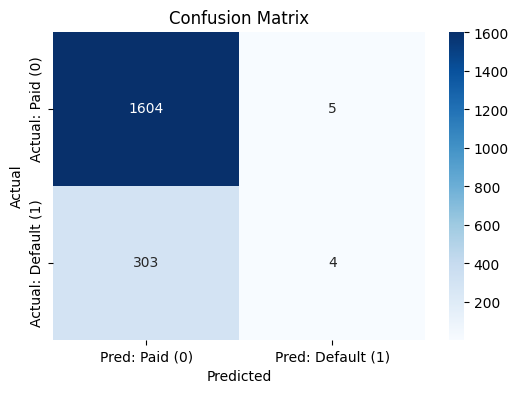

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Print detailed metrics (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_valid, preds))

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_valid, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Paid (0)', 'Pred: Default (1)'],
            yticklabels=['Actual: Paid (0)', 'Actual: Default (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.88      0.71      0.79      1609
           1       0.24      0.49      0.32       307

    accuracy                           0.67      1916
   macro avg       0.56      0.60      0.55      1916
weighted avg       0.78      0.67      0.71      1916



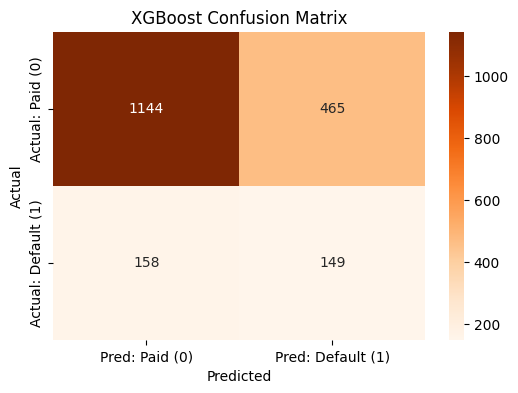

In [7]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define XGBoost with penalty for imbalanced data
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=5.25, # Heavier penalty for missing class 1
    random_state=42,
    eval_metric='logloss'
)

# 2. Put it in the pipeline with our preprocessor
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# 3. Train
xgb_pipeline.fit(X_train, y_train)

# 4. Predict
xgb_preds = xgb_pipeline.predict(X_valid)

# 5. Evaluate
print("Classification Report for XGBoost:")
print(classification_report(y_valid, xgb_preds))

cm_xgb = confusion_matrix(y_valid, xgb_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred: Paid (0)', 'Pred: Default (1)'],
            yticklabels=['Actual: Paid (0)', 'Actual: Default (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('XGBoost Confusion Matrix')
plt.show()

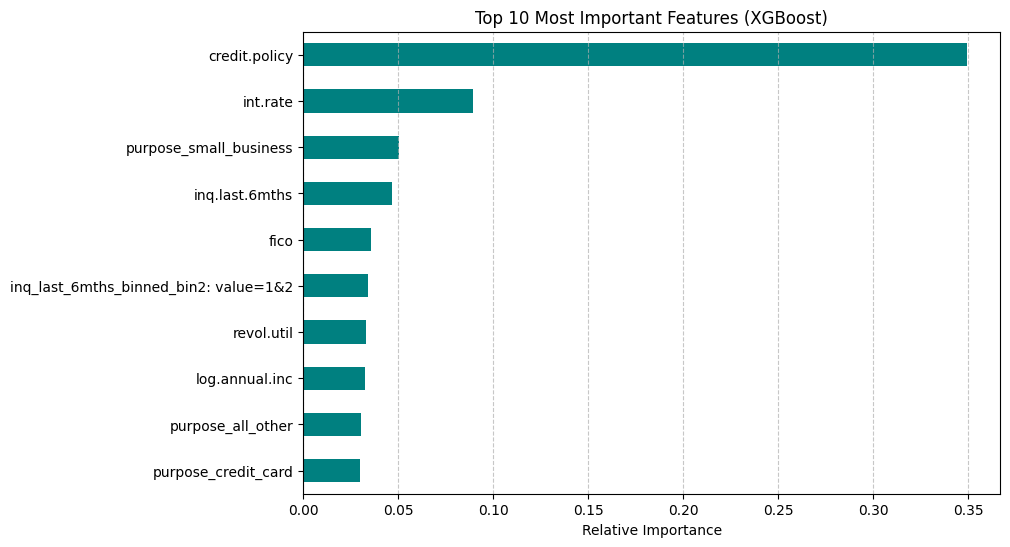

In [8]:

import matplotlib.pyplot as plt

# 1. Extract feature names directly from the fitted preprocessor
all_features = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Clean up column names (removes prefixes like 'num__' and 'cat__')
all_features = [f.split('__')[-1] for f in all_features]

# 2. Extract feature importances from XGBoost
importances = xgb_pipeline.named_steps['model'].feature_importances_

# 3. Create Series and plot Top 10 Features
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feat_imp.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()